In [19]:
import cartopy.crs as ccrs
import pandas as pd
import xarray as xr
import numpy as np

import glob
import os
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
lat_min=35
lon_min=-55
lat_max=55
lon_max=-25

In [6]:
# etopo file
ef = '/home/soontiensn/data/ocn-nav/ETOPO1_Bed_g_gmt4.grd'
etopo = xr.open_dataset(ef)
esel = etopo.sel(x=slice(lon_min, lon_max), y=slice(lat_min, lat_max))

In [7]:
stokes = glob.glob('data/stokes_*')
SVPs = glob.glob('data/SVP_*')
spotter = 'data/SPOT-1017_2021-12-06_2022-02-12_download.csv'
oskers = 'data/OSKERS_DFO-GrandBanks2021.csv'

In [44]:
def plot_bathymetry( ax, etopo):
    lons = etopo.x.values
    lats = etopo.y.values
    lons, lats = np.meshgrid(lons,lats)
    bathy = etopo.z.values
    levels = [-500, -100,]
    CS = ax.contour(lons, lats, bathy,levels, linestyles='solid', linewidth=0.05,colors='grey', transform=ccrs.PlateCarree())
    ax.clabel(CS, CS.levels, inline=True, fmt='%1.0f', fontsize=12)

In [12]:
def plot_spotter(fname, ax):
    d = pd.read_csv(fname)
    lon = d['Longitude (deg)'].values
    lat= d['Latitude (deg)'].values
    ax.plot(lon, lat, color='b', label='Spotter', transform=ccrs.PlateCarree())
        

In [47]:
def plot_SVPs(files, ax):
    count=0
    for f in files:
        d = pd.read_csv(f)
        print(d)
        lon, lat = d[' LONGITUDE'].values,d[' LATITUDE'].values
        if count==0:
            ax.plot(lon, lat, '.-', label='SVPs', transform=ccrs.PlateCarree())
        else:
            ax.plot(lon, lat,color='r', label='_nolabel__', transform=ccrs.PlateCarree())
        count+=1

In [48]:
def plot_stokes(files, ax):
    count=0
    for f in files:
        d = pd.read_csv(f)
        print(f)
        print(d)
        d = d[d[' Latitude'].between(-90,90)]
        lon, lat = d[' Longitude'].values,d[' Latitude'].values
        ax.plot(lon,lat, '.-', label=f'stokes {count}', transform=ccrs.PlateCarree())
        count+=1

In [49]:
def plot_oskers(file, ax):
    d = pd.read_csv(file)
    dg = d.groupby('Device')
    count=0
    for name, g in dg:
        lon , lat = g['Longitude'].values,g['Latitude'].values
        if count ==0:
            ax.plot(lon,lat,color='g', label='Osker', transform=ccrs.PlateCarree())
        else:
            ax.plot(lon,lat,color='g', label='__nolabel__', transform=ccrs.PlateCarree())
        count+=1

          Data Date (UTC)   LATITUDE   LONGITUDE   FMTID   YEAR   MONTH   DAY  \
0     2022-02-11 08:00:00    44.3572    -51.5922       0   2022       2    11   
1     2022-02-11 07:00:00    44.3560    -51.5908       0   2022       2    11   
2     2022-02-11 06:00:00    44.3548    -51.5884       0   2022       2    11   
3     2022-02-11 05:00:00    44.3542    -51.5864       0   2022       2    11   
4     2022-02-11 04:00:00    44.3538    -51.5838       0   2022       2    11   
...                   ...        ...         ...     ...    ...     ...   ...   
1578  2021-12-07 07:00:00    45.0884    -51.6874       0   2021      12     7   
1579  2021-12-07 06:00:00    45.0912    -51.6870       0   2021      12     7   
1580  2021-12-07 05:00:00    45.0952    -51.6898       0   2021      12     7   
1581  2021-12-07 04:00:00    45.0996    -51.6960       0   2021      12     7   
1582  2021-12-07 03:10:00    45.1022    -51.7032       0   2021      12     7   

       HOUR   MIN    SST   

/home/soontiensn/miniconda-new/envs/griddrift/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linewidth'
  result = super().contour(*args, **kwargs)


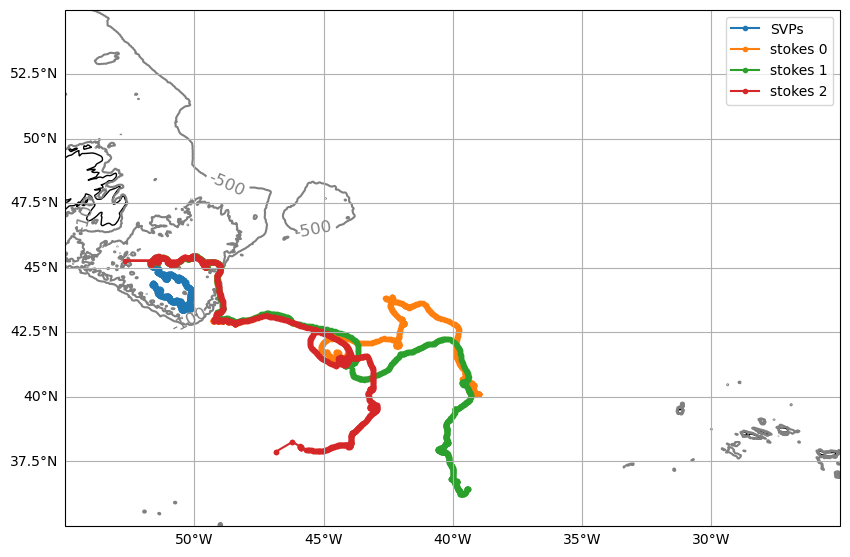

In [51]:
fig, ax = plt.subplots(1,1,figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
plot_bathymetry(ax,esel)
#plot_oskers(oskers, ax)
plot_SVPs([SVPs[3]], ax)
plot_stokes([stokes[0], stokes[3], stokes[-1]], ax)
#plot_spotter(spotter, ax)
ax.legend()
ax.gridlines(draw_labels=['bottom','left'])
ax.coastlines()

In [52]:
fig.savefig('2021-grouped-deployment.png', bbox_inches='tight', dpi=300)